<a href="https://colab.research.google.com/github/Chaidir110/PCVK_Ganjil_2025/blob/main/week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#D1. Praktikum Deteksi Obyek Dasar

In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Template matching

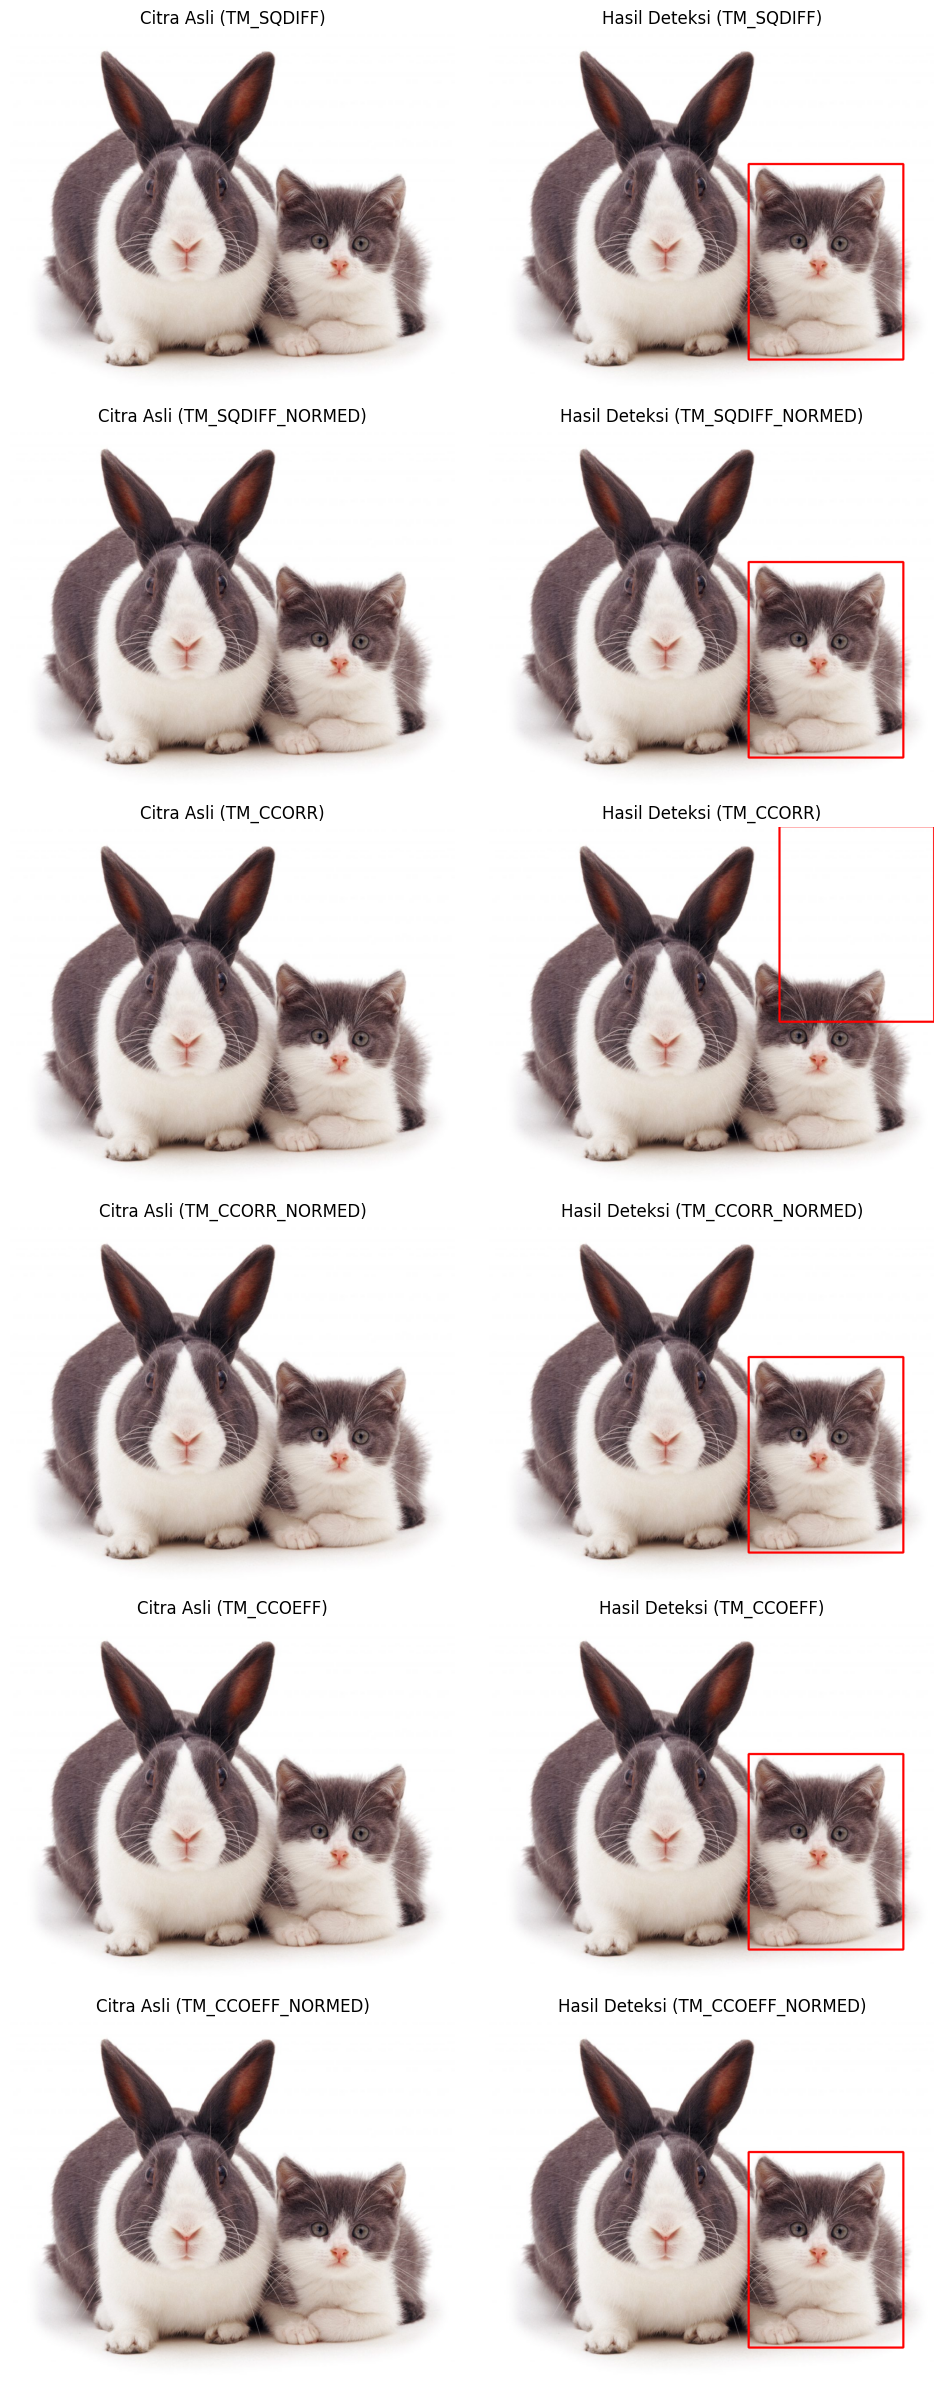

In [ ]:
# Template Matching - versi (Colab Ready, tampilan menurun)
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def template_matching(image_path, template_path, method_choice=0):
    # Load gambar utama dan template
    img = cv.imread(image_path, cv.IMREAD_COLOR)
    templ = cv.imread(template_path, cv.IMREAD_COLOR)

    if img is None or templ is None:
        raise ValueError("Gambar atau template tidak ditemukan!")

    # Daftar metode
    methods = [
        ("TM_SQDIFF", cv.TM_SQDIFF),
        ("TM_SQDIFF_NORMED", cv.TM_SQDIFF_NORMED),
        ("TM_CCORR", cv.TM_CCORR),
        ("TM_CCORR_NORMED", cv.TM_CCORR_NORMED),
        ("TM_CCOEFF", cv.TM_CCOEFF),
        ("TM_CCOEFF_NORMED", cv.TM_CCOEFF_NORMED)
    ]

    # Kalau user pilih salah satu metode (1–6)
    if method_choice in range(1, 7):
        methods = [methods[method_choice - 1]]

    th, tw = templ.shape[:2]

    # Buat figure dengan jumlah baris = jumlah metode, 2 kolom (asli + hasil)
    n_methods = len(methods)
    plt.figure(figsize=(10, 4 * n_methods))

    for i, (name, method) in enumerate(methods):
        # Copy gambar untuk hasil deteksi
        img_display = img.copy()

        # Matching
        result = cv.matchTemplate(img, templ, method)
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)

        # Tentukan titik terbaik (min atau max)
        if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
            top_left = min_loc
        else:
            top_left = max_loc

        bottom_right = (top_left[0] + tw, top_left[1] + th)
        cv.rectangle(img_display, top_left, bottom_right, (0, 0, 255), 3)

        # ---- Tampilkan citra asli ----
        plt.subplot(n_methods, 2, i*2 + 1)
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(f"Citra Asli ({name})")
        plt.axis('off')

        # ---- Tampilkan hasil deteksi ----
        plt.subplot(n_methods, 2, i*2 + 2)
        plt.imshow(cv.cvtColor(img_display, cv.COLOR_BGR2RGB))
        plt.title(f"Hasil Deteksi ({name})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# === Pemanggilan di Google Colab ===
image_path = "/content/drive/MyDrive/RPL/PCVK/object detection/cats_and_bunnies.jpg"
template_path = "/content/drive/MyDrive/RPL/PCVK/object detection/cat2_templatejpg.jpg"

# method_choice = 0 → semua metode
# method_choice = 1–6 → satu metode tertentu
template_matching(image_path, template_path, method_choice=0)

## Template matching untuk multiple object

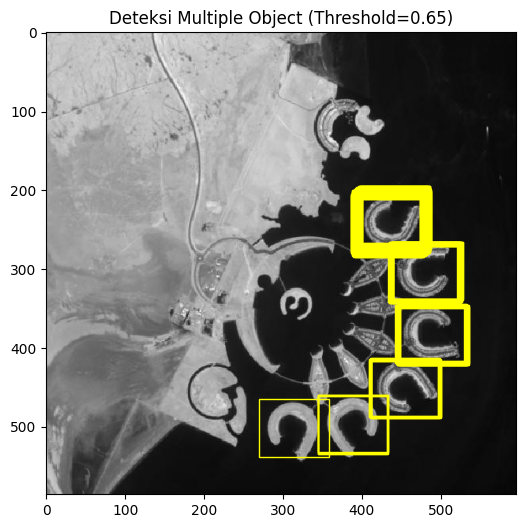

Jumlah objek terdeteksi: 263


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def load_gray(path):
    img = Image.open(path).convert('L')  # ubah ke grayscale
    return np.array(img, dtype=np.float32)

def normalized_cross_correlation(img, template):
    h, w = img.shape
    th, tw = template.shape
    result = np.zeros((h - th + 1, w - tw + 1), dtype=np.float32)

    # normalisasi template
    t_mean = np.mean(template)
    t_std = np.std(template)
    template_n = (template - t_mean) / (t_std + 1e-6)

    # sliding window
    for y in range(result.shape[0]):
        for x in range(result.shape[1]):
            patch = img[y:y+th, x:x+tw]
            p_mean = np.mean(patch)
            p_std = np.std(patch)
            patch_n = (patch - p_mean) / (p_std + 1e-6)
            result[y, x] = np.sum(patch_n * template_n)

    # normalisasi hasil agar 0–1
    result = (result - np.min(result)) / (np.max(result) - np.min(result))
    return result

def template_matching_multiple(image_path, template_path, threshold=0.8):
    # Load citra
    img = load_gray(image_path)
    template = load_gray(template_path)
    th, tw = template.shape

    # Hitung korelasi
    corr_map = normalized_cross_correlation(img, template)

    # Deteksi titik-titik dengan kemiripan tinggi
    y_coords, x_coords = np.where(corr_map >= threshold)

    # Tampilkan hasil
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(img, cmap='gray')
    for (x, y) in zip(x_coords, y_coords):
        rect = plt.Rectangle((x, y), tw, th, edgecolor='yellow', facecolor='none', linewidth=1)
        ax.add_patch(rect)
    ax.set_title(f"Deteksi Multiple Object (Threshold={threshold})")
    plt.show()

    return corr_map, list(zip(x_coords, y_coords))

# === Contoh Pemanggilan di Google Colab ===
image_path = "/content/drive/MyDrive/RPL/PCVK/object detection/bahrain.jpg"
template_path = "/content/drive/MyDrive/RPL/PCVK/object detection/bahrain-template.jpg"

corr_map, detections = template_matching_multiple(image_path, template_path, threshold=0.65)
print(f"Jumlah objek terdeteksi: {len(detections)}")

Implementasikan metode Sobel Edge Detection, Canny Edge Detection, dan Laplacian Edge Detection pada OpenCV dengan menggunakan gambar car-park.jpg

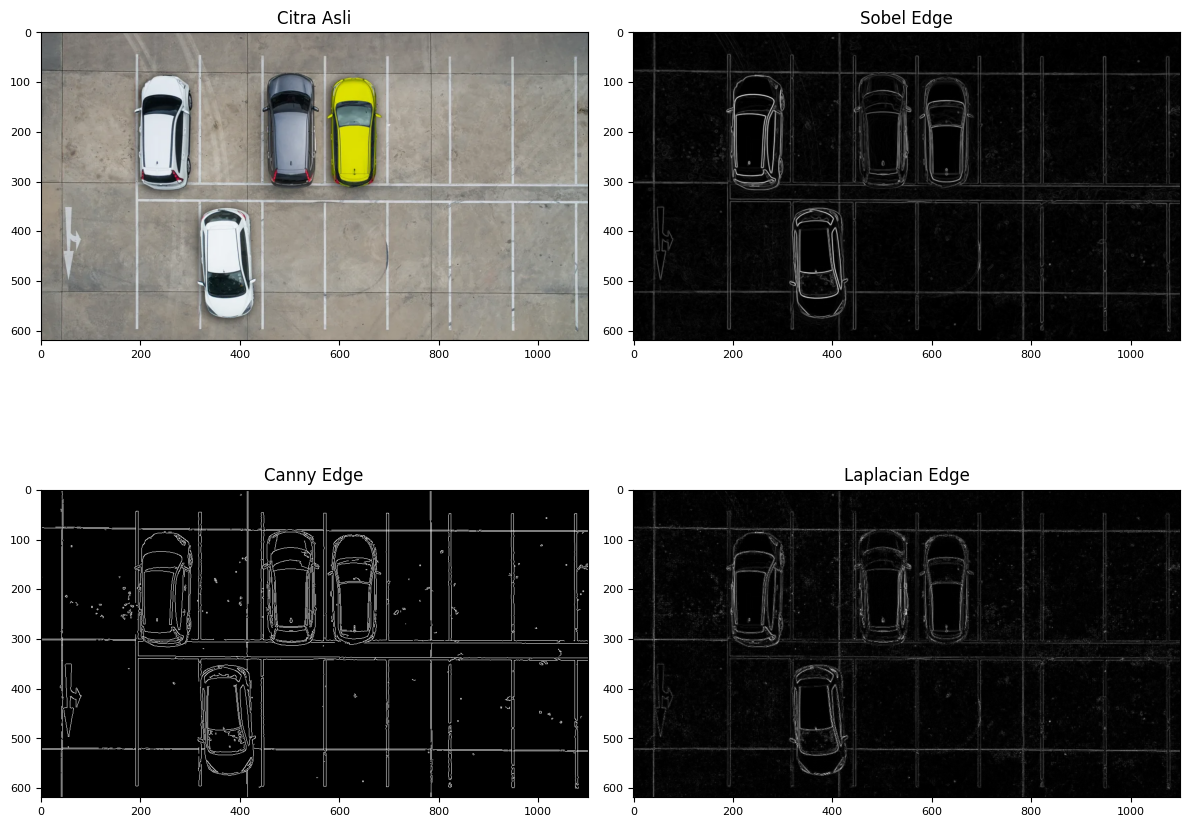

In [ ]:
# Import library
import cv2
import matplotlib.pyplot as plt

# Baca gambar dari Google Drive
img_path = '/content/drive/MyDrive/RPL/PCVK/object detection/car-park.jpg'
img = cv2.imread(img_path)

# Ubah ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================
# 1️⃣ Sobel Edge Detection
# ==========================
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

# ==========================
# 2️⃣ Canny Edge Detection
# ==========================
canny_edges = cv2.Canny(gray, 100, 200)

# ==========================
# 3️⃣ Laplacian Edge Detection
# ==========================
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

# ==========================
# 4️⃣ Tampilkan hasil (dengan angka ukuran)
# ==========================
titles = ['Citra Asli', 'Sobel Edge', 'Canny Edge', 'Laplacian Edge']
images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB), sobel_combined, canny_edges, laplacian]

plt.figure(figsize=(12,10))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=12)
    plt.tick_params(axis='both', which='both', labelsize=8)  # tampilkan angka ukuran kecil

plt.tight_layout()
plt.show()

Implementasikan metode Harris Corner Detection dan Shi-Tomasi Detection pada OpenCV

Harris Corner Detection

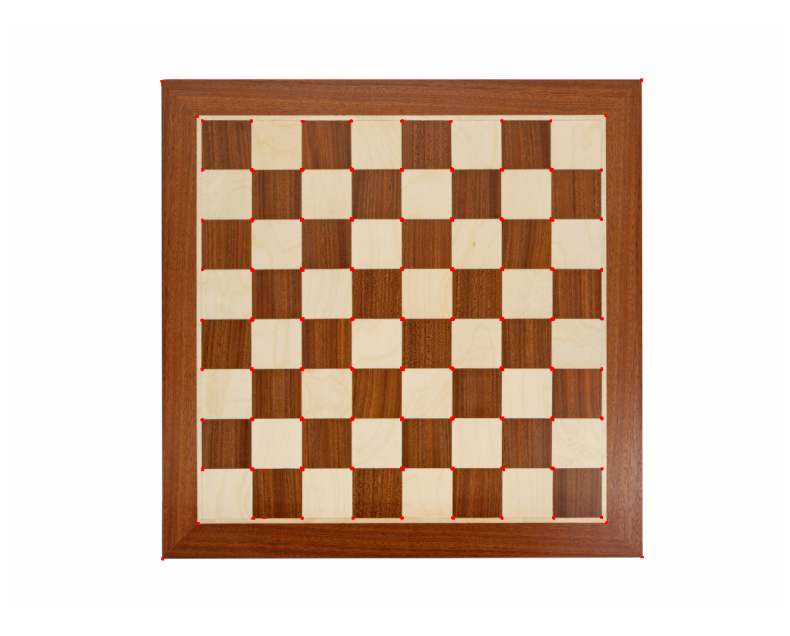

In [ ]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow

filename = '/content/drive/MyDrive/RPL/PCVK/object detection/chess-board.jpg'
img = cv.imread(filename)

gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
gray = np.float32(gray)
dst = cv.cornerHarris(gray,2,3,0.04)

#result is dilated for marking the corners, not important
dst = cv.dilate(dst,None)

# Threshold for an optimal value, it may vary depending on the image.
img[dst>0.01*dst.max()]=[0,0,255]

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#tampilan
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

Shi-Tomasi Detection

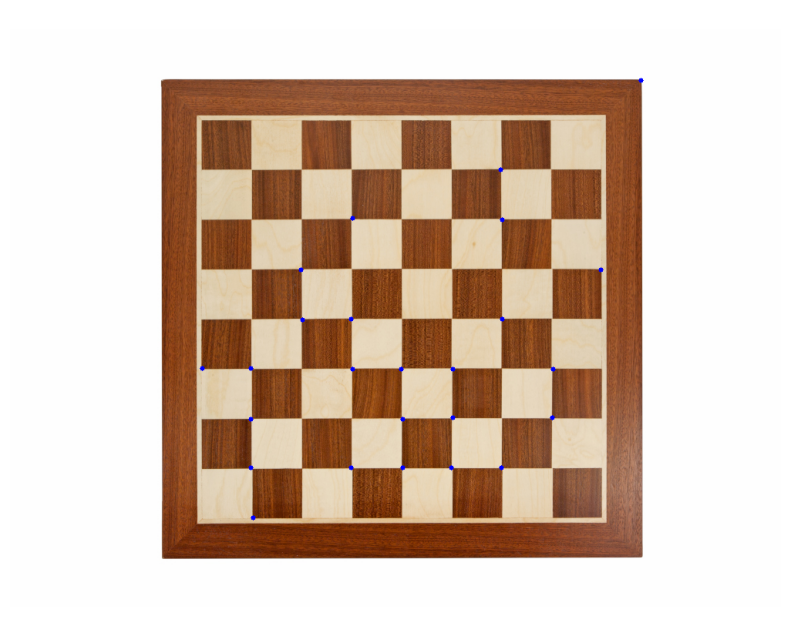

In [ ]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

img = cv.imread('/content/drive/MyDrive/RPL/PCVK/object detection/chess-board.jpg')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

corners = cv.goodFeaturesToTrack(gray,25,0.01,10)
corners = corners.astype(int)  # Ganti np.int0 menjadi astype(int)

for i in corners:
    x,y = i.ravel()
    cv.circle(img,(x,y),3,255,-1)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

#tampilan
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

Implementasikan metode Hough Transform pada OpenCV

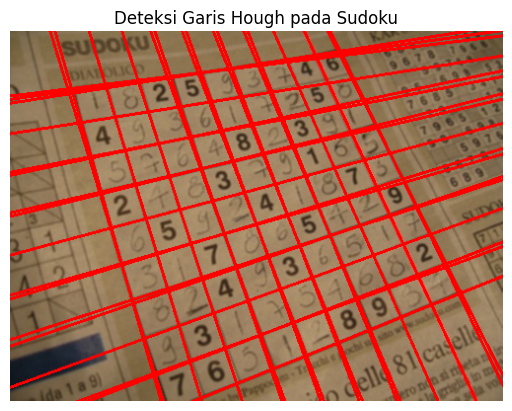

In [12]:
import cv2

# Baca dan ubah gambar ke grayscale
img = cv2.imread("/content/drive/MyDrive/RPL/PCVK/object detection/sudoku.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Deteksi tepi dan perkuat garis
edges = cv2.Canny(gray, 90, 150)
edges = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=1)
edges = cv2.erode(edges, np.ones((5,5), np.uint8), iterations=1)

# Deteksi garis dengan Hough Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * (a))
        x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * (a))
        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Tampilkan hasil
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Deteksi Garis Hough pada Sudoku")
plt.axis("off")
plt.show()

Implementasikan fungsi findContours() pada OpenCV

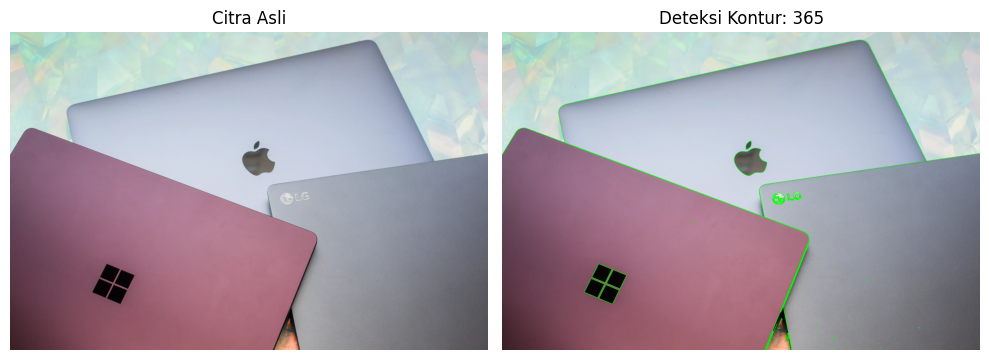

In [20]:
import cv2 as cv
import matplotlib.pyplot as plt

# Baca dan ubah gambar ke grayscale
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/object detection/laptop.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Deteksi tepi dan kontur
edges = cv.Canny(gray, 50, 150)
contours, _ = cv.findContours(edges, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Gambar kontur
contour_img = img.copy()
cv.drawContours(contour_img, contours, -1, (0, 255, 0), 2)

# Tampilkan hasil
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Citra Asli")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(contour_img, cv.COLOR_BGR2RGB))
plt.title(f"Deteksi Kontur: {len(contours)}")
plt.axis('off')
plt.tight_layout()
plt.show()

#D2. Praktikum Feature Matching dan Face Detection

Lakukan Face Detection

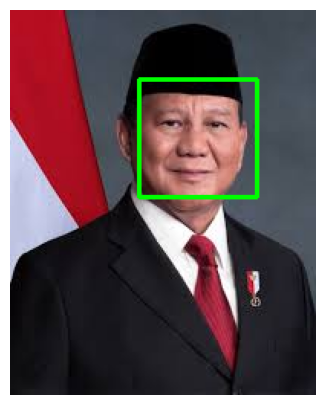

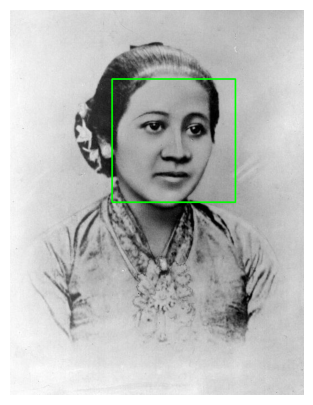

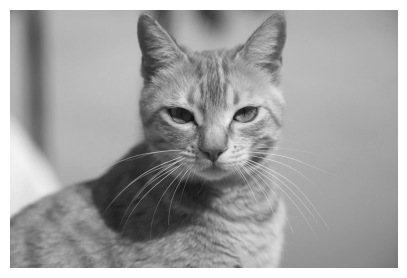

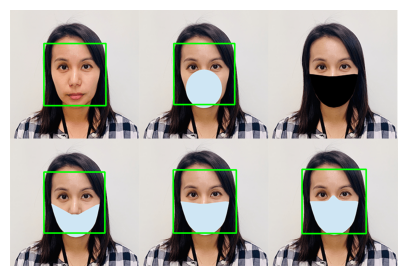

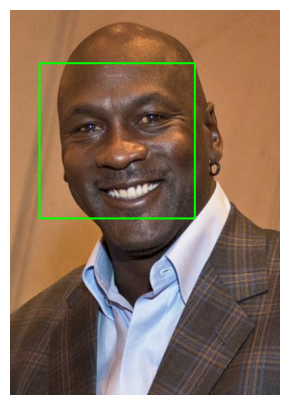

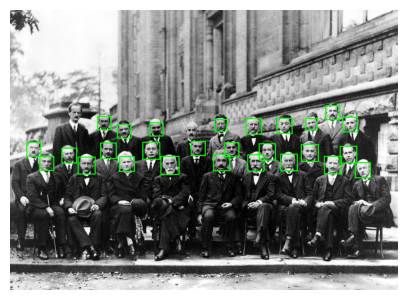

In [14]:
# Path model Haarcascade
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_frontalface_alt.xml')
# Daftar gambar
gambar_list = [
    '/content/drive/MyDrive/RPL/PCVK/object detection/prabowo.jpg',
    '/content/drive/MyDrive/RPL/PCVK/object detection/kartini.jpg',
    '/content/drive/MyDrive/RPL/PCVK/object detection/kucing2.jpg',
    '/content/drive/MyDrive/RPL/PCVK/object detection/mask.png',
    '/content/drive/MyDrive/RPL/PCVK/object detection/mjordan.jpg',
    '/content/drive/MyDrive/RPL/PCVK/object detection/solvayconf.jpg'
]
# Loop untuk deteksi di tiap gambar
for path in gambar_list:
    img = cv.imread(path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    faces = cascade_wajah.detectMultiScale(img_rgb, scaleFactor=1.1, minNeighbors=5)

    for (x, y, w, h) in faces:
        cv.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.figure(figsize=(5,5))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


Lakukan deteksi wajah kucing hingga muncul rectangle pada bagian wajahnya.

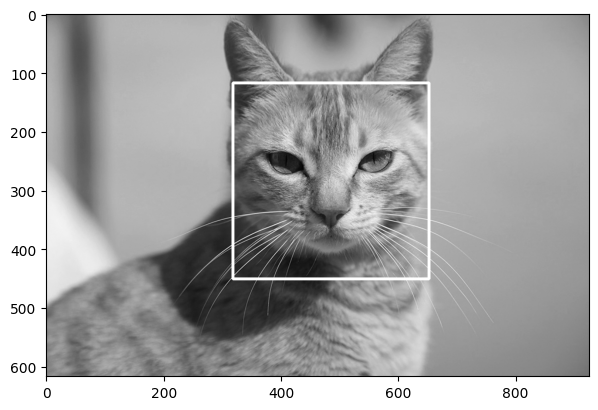

In [ ]:
cascade_wajah = cv.CascadeClassifier('/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_frontalcatface.xml')
#sesuai posisi folder Haarcascade masing-masing
kucing = cv.imread('/content/drive/MyDrive/RPL/PCVK/object detection/kucing2.jpg',0)
roi_wajah = cascade_wajah.detectMultiScale(kucing)
for(x,y,w,h) in roi_wajah:
  cv.rectangle(kucing,(x,y),(x+w,y+h),(255,255,255),3)
plt.figure(figsize = (7,7))
plt.imshow(kucing, cmap='gray')

eyes detection pada wajah Pak Prabowo

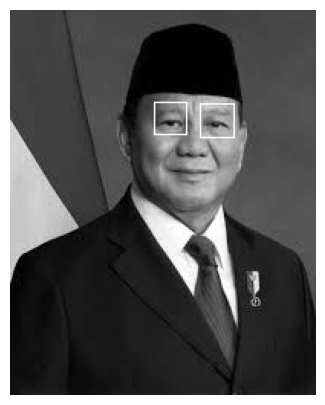

In [ ]:
# Muat Haar Cascade untuk mata kanan dan kiri
right_eye_cascade = cv.CascadeClassifier('/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_righteye_2splits.xml')
left_eye_cascade = cv.CascadeClassifier('/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_lefteye_2splits.xml')

# Baca gambar Pak Prabowo
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/object detection/prabowo.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Deteksi mata kanan
eyes_right = right_eye_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
# Deteksi mata kiri
eyes_left = left_eye_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Gambar persegi untuk hasil deteksi (di gambar gray)
for (x, y, w, h) in eyes_right:
    cv.rectangle(gray, (x, y), (x+w, y+h), (255, 255, 255), 1)   # putih untuk mata kanan
for (x, y, w, h) in eyes_left:
    cv.rectangle(gray, (x, y), (x+w, y+h), (255, 255, 255), 1)   # abu terang untuk mata kiri

# Tampilkan hasil dalam format grayscale
plt.figure(figsize=(5,5))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()


Lakukan deteksi senyuman pada gambar

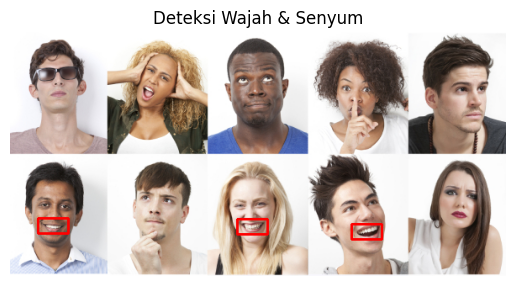

In [17]:
import cv2 as cv
import matplotlib.pyplot as plt

# Load model Haar Cascade
face_cascade = cv.CascadeClassifier('/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_frontalface_default.xml')
smile_cascade = cv.CascadeClassifier('/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_smile.xml')

# Baca gambar dan ubah ke grayscale
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/object detection/people.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Deteksi wajah
faces = face_cascade.detectMultiScale(gray)

# Salin gambar untuk hasil
result = img.copy()

# Deteksi senyum di setiap wajah
for (x, y, w, h) in faces:
    roi_gray = gray[y:y + h, x:x + w]
    roi_color = result[y:y + h, x:x + w]

    smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.3, minNeighbors=8)

    if len(smiles) > 0:
        for (sx, sy, sw, sh) in smiles:
            cv.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)

# Tampilkan hasil
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title("Deteksi Wajah & Senyum")
plt.axis('off')
plt.show()

Lakukan Face Tracking menggunakan Google Colab.

In [31]:
# import dependencies
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time

In [32]:
# function to convert the JavaScript object into an OpenCV image
def js_to_image(js_reply):
  """
  Params:
          js_reply: JavaScript object containing image from webcam
  Returns:
          img: OpenCV BGR image
  """
  # decode base64 image
  image_bytes = b64decode(js_reply.split(',')[1])
  # convert bytes to numpy array
  jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
  # decode numpy array into OpenCV BGR image
  img = cv2.imdecode(jpg_as_np, flags=1)

  return img

# function to convert OpenCV Rectangle bounding box image into base64 byte string to be overlayed on video stream
def bbox_to_bytes(bbox_array):
  """
  Params:
          bbox_array: Numpy array (pixels) containing rectangle to overlay on video stream.
  Returns:
        bytes: Base64 image byte string
  """
  # convert array into PIL image
  bbox_PIL = PIL.Image.fromarray(bbox_array, 'RGBA')
  iobuf = io.BytesIO()
  # format bbox into png for return
  bbox_PIL.save(iobuf, format='png')
  # format return string
  bbox_bytes = 'data:image/png;base64,{}'.format((str(b64encode(iobuf.getvalue()), 'utf-8')))

  return bbox_bytes

In [33]:
# initialize the Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.samples.findFile(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'))

In [34]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)

  # get photo data
  data = eval_js('takePhoto({})'.format(quality))
  # get OpenCV format image
  img = js_to_image(data)
  # grayscale img
  gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
  print(gray.shape)
  # get face bounding box coordinates using Haar Cascade
  faces = face_cascade.detectMultiScale(gray)
  # draw face bounding box on image
  for (x,y,w,h) in faces:
      img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
  # save image
  cv2.imwrite(filename, img)

  return filename

<IPython.core.display.Javascript object>

(480, 640)
Saved to photo.jpg


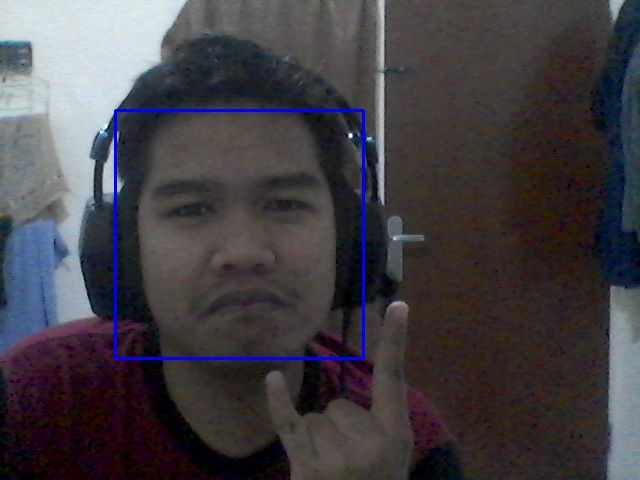

In [37]:
try:
  filename = take_photo('photo.jpg')
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

Lakukan Blurring pada bagian wajah yang terdeteksi.

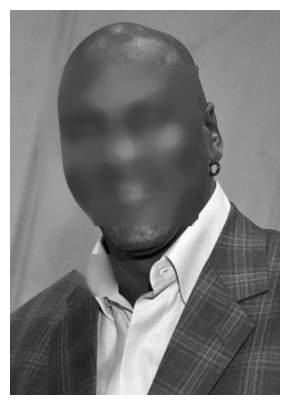

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

# Path gambar dan cascade
img_path = '/content/drive/MyDrive/RPL/PCVK/object detection/mjordan.jpg'
cascade_path = '/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_frontalface_default.xml'

# Membaca gambar
img = cv.imread(img_path)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Load cascade untuk deteksi wajah
face_cascade = cv.CascadeClassifier(cascade_path)

# Deteksi wajah
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))

# Copy citra grayscale untuk hasil blur
gray_blur = gray.copy()

# Lakukan blurring pada area wajah yang terdeteksi
for (x, y, w, h) in faces:
    face_roi = gray_blur[y:y+h, x:x+w]
    face_blur = cv.medianBlur(face_roi, 35)
    gray_blur[y:y+h, x:x+w] = face_blur

# Tampilkan hasil
plt.figure(figsize=(10,5))
plt.imshow(gray_blur, cmap='gray')
plt.axis('off')
plt.show()

Mengolah gambar KTM

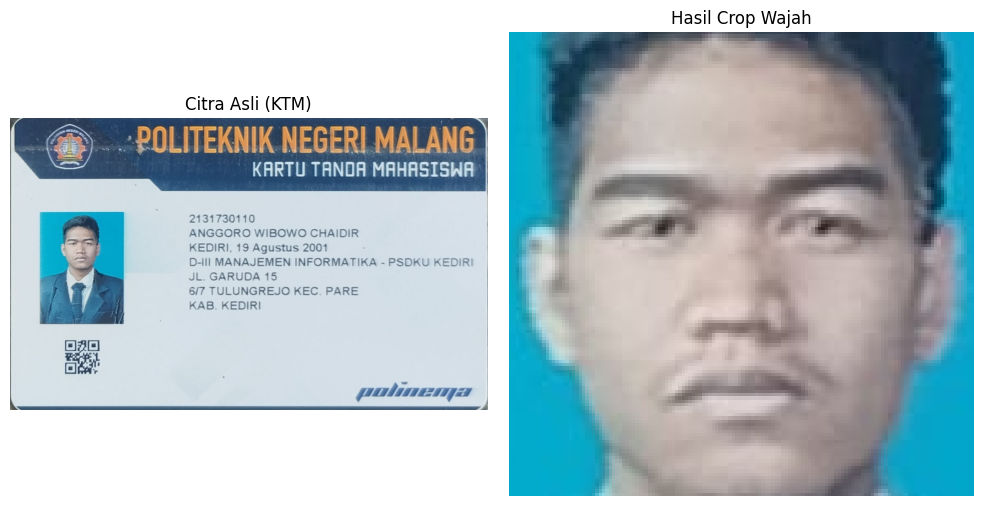

In [24]:
import cv2 as cv
import matplotlib.pyplot as plt

# Load model deteksi wajah
face_cascade = cv.CascadeClassifier('/content/drive/MyDrive/RPL/PCVK/object detection/haarcascades/haarcascade_frontalface_alt.xml')

# Baca gambar dan ubah ke format yang diperlukan
img = cv.imread('/content/drive/MyDrive/RPL/PCVK/ktm ori.jpeg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Deteksi wajah
faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30, 30))

# Ambil area wajah pertama (diasumsikan ada wajah)
x, y, w, h = faces[0]
face_crop = cv.cvtColor(img[y:y+h, x:x+w], cv.COLOR_BGR2RGB)

# Tampilkan hasil
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli (KTM)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(face_crop)
plt.title("Hasil Crop Wajah")
plt.axis('off')
plt.tight_layout()
plt.show()

Lakukan Deteksi Obyek KTM pada gambar yang berisi KTM dengan barang lainnya dengan menggunakan Konsep Feature Matching

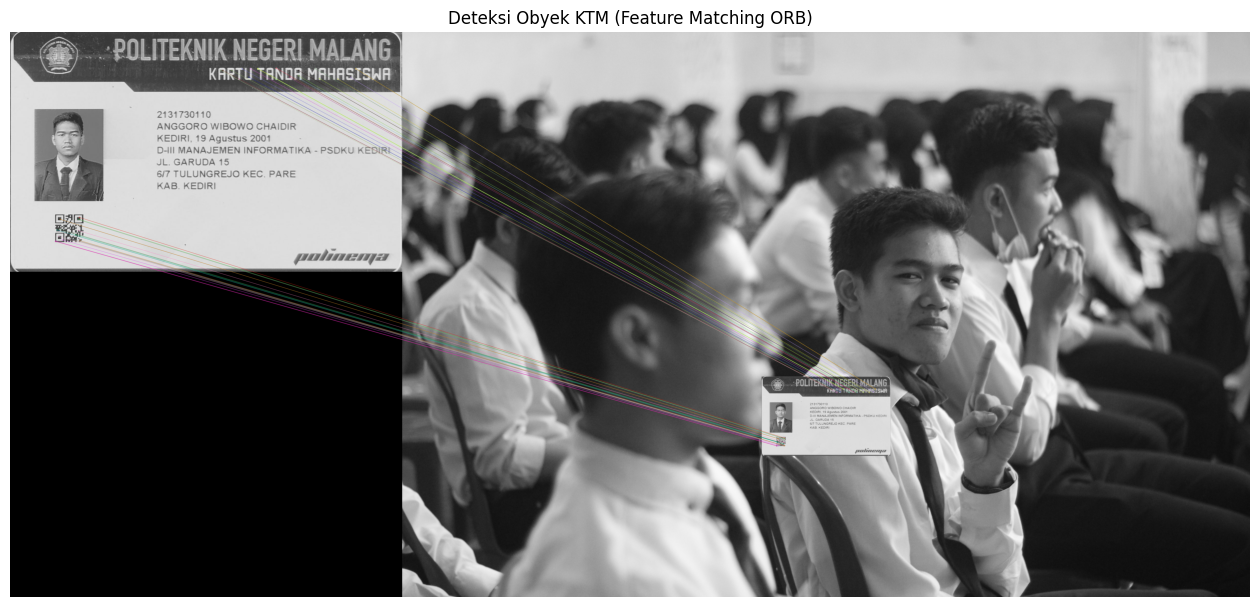

In [30]:
import cv2 as cv
import matplotlib.pyplot as plt

# === 1️⃣ Baca gambar referensi (KTM) dan gambar uji ===
img_ktm = cv.imread('/content/drive/MyDrive/RPL/PCVK/ktm ori.jpeg', cv.IMREAD_GRAYSCALE)
img_scene = cv.imread('/content/drive/MyDrive/RPL/PCVK/object detection/ktm + lain.jpg', cv.IMREAD_GRAYSCALE)

# === 2️⃣ Perbesar gambar KTM agar lebih jelas saat dibandingkan ===
scale_percent = 150  # ubah persentase sesuai kebutuhan (misal 150%)
width = int(img_ktm.shape[1] * scale_percent / 100)
height = int(img_ktm.shape[0] * scale_percent / 100)
img_ktm_large = cv.resize(img_ktm, (width, height), interpolation=cv.INTER_CUBIC) #memperbesar gambar dengan hasil yang lebih halus

# === 3️⃣ Inisialisasi ORB ===
orb = cv.ORB_create(nfeatures=1000)

# === 4️⃣ Deteksi keypoints & compute descriptors ===
kp1, des1 = orb.detectAndCompute(img_ktm_large, None)
kp2, des2 = orb.detectAndCompute(img_scene, None)

# === 5️⃣ Pencocokan fitur menggunakan Brute-Force Matcher ===
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# === 6️⃣ Gambar hasil pencocokan ===
result = cv.drawMatches(img_ktm_large, kp1, img_scene, kp2, matches[:40], None, flags=2)

# === 7️⃣ Tampilkan hasil ===
plt.figure(figsize=(16, 8))
plt.imshow(result, cmap='gray')
plt.title("Deteksi Obyek KTM (Feature Matching ORB)")
plt.axis('off')
plt.show()

#Tambahan Tugas Praktikum:

In [75]:
import os
import tqdm
import cv2
import random
import numpy as np
import pickle

# === Direktori data training ===
DATADIR = "/content/drive/MyDrive/RPL/PCVK/training/"
training_data = []
width, height = 100, 100  # ukuran citra input

# === Looping direktori angka 0–9 ===
dirs = sorted(os.listdir(DATADIR))

for char_name in dirs:
    path = os.path.join(DATADIR, char_name)
    class_number = dirs.index(char_name)

    for img_name in tqdm.tqdm(os.listdir(path), desc=f"Memproses {char_name}"):
        try:
            img_array = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (width, height))
            training_data.append([new_array, class_number])
        except Exception as e:
            print(f"Gagal memproses {img_name}: {e}")
            pass

# === Acak urutan data ===
random.shuffle(training_data)

# === Pisahkan fitur dan label ===
X = []
Y = []

for feature, label in training_data:
    X.append(feature)
    Y.append(label)

# === Bentuk array numpy untuk model DL ===
X = np.array(X).reshape(-1, width, height, 1)
Y = np.array(Y)

# === Simpan data ke file pickle ===
with open("X.pickle", "wb") as pickle_out:
    pickle.dump(X, pickle_out)

with open("Y.pickle", "wb") as pickle_out:
    pickle.dump(Y, pickle_out)

print("✅ Data training berhasil disimpan ke X.pickle dan Y.pickle")

Memproses 9: 100%|██████████| 1/1 [00:00<00:00, 60.39it/s]

✅ Data training berhasil disimpan ke X.pickle dan Y.pickle


training

In [76]:
import pickle
import numpy as np
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, ZeroPadding2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# === 1️⃣ Load data dari file pickle ===
with open("X.pickle", "rb") as f:
    X = pickle.load(f)

with open("Y.pickle", "rb") as f:
    Y = pickle.load(f)

# === 2️⃣ Normalisasi dan ubah label ke one-hot ===
X = np.array(X) / 255.0
Y = to_categorical(Y)

width, height = 100, 100

# === 3️⃣ Arsitektur CNN ===
inputs = Input(shape=(width, height, 1))

x = ZeroPadding2D(padding=(2, 2))(inputs)
x = Conv2D(16, (5, 5), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu')(x)
x = Conv2D(32, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu')(x)
x = Flatten()(x)

x = Dense(256, activation='relu')(x)
x = Dense(64, activation='relu')(x)

# === 4️⃣ Output layer ===
# Ubah jumlah neuron sesuai jumlah kelas (misal 10 untuk angka 0–9)
outputs = Dense(10, activation='softmax')(x)

# === 5️⃣ Kompilasi model ===
adam = Adam(learning_rate=0.0001)
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# === 6️⃣ Training model ===
model.fit(X, Y, epochs=20, batch_size=32, verbose=1)

# === 7️⃣ Simpan model dengan ekstensi yang benar ===
model.save('/content/drive/MyDrive/RPL/PCVK/object detection/anpr_model.keras')

print("✅ Model telah selesai dilatih dan disimpan sebagai 'anpr_model.keras'")


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.1000 - loss: 2.3008
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.1000 - loss: 2.2888
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.1000 - loss: 2.2751
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.1000 - loss: 2.2590
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.1000 - loss: 2.2415
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.3000 - loss: 2.2205
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.3000 - loss: 2.1996
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.3000 - loss: 2.1762
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.4000 - loss: 2.1523
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.4000 - loss: 2.1266
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.6000 - loss: 2.1009
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.5000 - loss:

In [77]:
import os
import cv2
import tensorflow as tf
import numpy as np

data_dir_training = "/content/drive/MyDrive/RPL/PCVK/training/"
data_dir_testing = "/content/drive/MyDrive/RPL/PCVK/testing"
dirs = []
width, height = 100, 100

model = tf.keras.models.load_model("/content/drive/MyDrive/RPL/PCVK/object detection/anpr_model.keras")

for char_name in sorted(os.listdir(data_dir_training)):
    dirs.append(char_name)

for car in sorted(os.listdir(data_dir_testing)):
    temp = ""
    for char_img in sorted(os.listdir(os.path.join(data_dir_testing, car))):
        img_array = cv2.imread(os.path.join(data_dir_testing, car, char_img), cv2.IMREAD_ANYCOLOR)
        new_array = cv2.resize(img_array, (width, height))
        new_array = np.array(new_array).reshape(-1, width, height, 1)

        new_array = new_array / 255.0

        prediction = model.predict(new_array)
        temp += dirs[np.argmax(prediction[0])]

    print("folder name: {} no: {}".format(car, temp))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
folder name: 0 no: 8
